In [ ]:
# https://github.com/clovaai/cord
# https://huggingface.co/datasets/naver-clova-ix/cord-v2

from datasets import load_dataset

ds = load_dataset("naver-clova-ix/cord-v2", split="test")

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 100
})


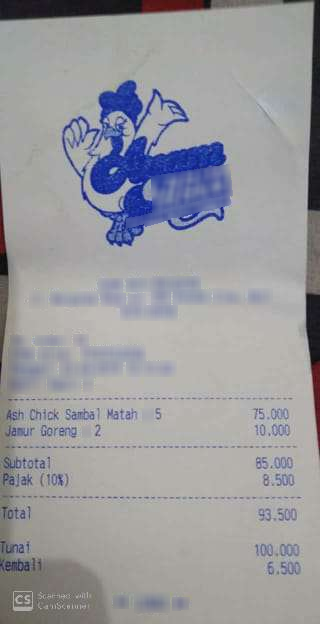

In [ ]:
print(ds)
ds[34]["image"]

In [ ]:
ds["ground_truth"][34]

'{"gt_parse": {"menu": [{"nm": "Ash Chick Sambal Matah", "cnt": "5", "price": "75.000"}, {"nm": "Jamur Goreng", "cnt": "2", "price": "10.000"}], "sub_total": {"subtotal_price": "85.000", "tax_price": "8.500"}, "total": {"total_price": "93.500", "cashprice": "100.000", "changeprice": "6.500"}}, "meta": {"version": "2.0.0", "split": "test", "image_id": 34, "image_size": {"width": 320, "height": 624}}, "valid_line": [{"words": [{"quad": {"x2": 26, "y3": 423, "x3": 26, "y4": 423, "x1": 6, "y1": 408, "x4": 6, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "Ash"}, {"quad": {"x2": 61, "y3": 423, "x3": 61, "y4": 423, "x1": 28, "y1": 408, "x4": 28, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "Chick"}, {"quad": {"x2": 105, "y3": 423, "x3": 105, "y4": 423, "x1": 64, "y1": 408, "x4": 64, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "Sambal"}, {"quad": {"x2": 138, "y3": 424, "x3": 138, "y4": 424, "x1": 107, "y1": 408, "x4": 107, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "M

In [ ]:
with open("ground_truth_example.json", "w") as f:
    f.write(ds["ground_truth"][34])

In [ ]:
from typing import Optional

from pydantic import BaseModel, Field


class Menu(BaseModel):
    nm: Optional[str] = Field(description="Name of menu")
    unitprice: Optional[str] = Field(description="Unit price of menu")
    cnt: Optional[str] = Field(description="Quantity of menu")
    price: Optional[str] = Field(description="Total price of menu")
    # num 	identification # of menu
    # discountprice 	discounted price of menu
    # itemsubtotal 	price of each menu after discount applied
    # vatyn 	whether the price includes tax or not
    # etc 	others
    # sub_nm 	name of submenu
    # sub_num 	identification # of submenu
    # sub_unitprice 	unit price of submenu
    # sub_cnt 	quantity of submenu
    # sub_discountprice 	discounted price of submenu
    # sub_price 	total price of submenu
    # sub_etc 	others


class SubTotal(BaseModel):
    subtotal_price: Optional[str] = Field(description="Subtotal price")
    tax_price: Optional[str] = Field(description="Tax amount")
    service_price: Optional[str] = Field(description="Service charge")
    # discount_price 	discounted price in total
    # subtotal_count 	Total number of items
    # othersvc_price 	added charge other than service charge
    # tax_and_service 	tax + service
    # etc 	others


class Total(BaseModel):
    total_price: Optional[str] = Field(description="Total price")
    cashprice: Optional[str] = Field(description="Amount of price paid in cash")
    changeprice: Optional[str] = Field(description="Amount of change in cash")
    # total_etc 	others
    # creditcardprice 	amount of price paid in credit/debit card
    # emoneyprice 	amount of price paid in emoney, point
    # menutype_cnt 	total count of type of menu
    # menuqty_cnt 	total count of quantity


class Receipt(BaseModel):
    menu: list[Menu]
    subtotal: Optional[SubTotal]
    total: Optional[Total]
    # void_total
    # void_menu

In [37]:
import os

from dotenv import load_dotenv
from interfaze import Interfaze

load_dotenv()

interfaze = Interfaze(
    api_key=os.environ["INTERFAZE_API_KEY"],
)

In [46]:
class IDSchema(BaseModel):
    first_name: str = Field(..., description="First name on the ID")
    last_name: str = Field(..., description="Last name on the ID")
    dob: str = Field(..., description="Date of birth on the ID")
    driver_licence_number: str = Field(
        ..., description="Driver licence number on the ID"
    )


response = interfaze.chat.completions.parse(
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Extract the details from this ID"},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": "https://r2public.jigsawstack.com/interfaze/examples/id.jpg"
                    },
                },
            ],
        }
    ],
    response_format=IDSchema,
)

print(response.choices[0].message.parsed)

first_name='IVÁN ICHET' last_name='MUÑOZ ESTRADA' dob='09/12/1987' driver_licence_number='Y4067081'


In [ ]:
with open("api_response_ocr_example.json", "w") as f:
    f.write(response.model_dump_json())